In [1]:
import platform
if 'mac' in platform.platform():
    BASE_DIR = "/Users/USER/vrtopc/"
    DATA_DIR = "/media/data/vrtopc"
else:
    BASE_DIR = "/home/USER/vr_to_pc/"
    DATA_DIR = "/media/data/vrtopc"

import sys
sys.path.append(BASE_DIR)

In [2]:
POS_DECODING_PERC_TRAIN = 0.5

LABELS_DEV = ['crawl', 'walk', 'run', 'adult']

LABELS_ROC = ['', '2s', '2.5s', '3s']

### Imports

In [3]:
import torch
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

from utils.metrics import get_spatial_correlation

import numpy as np
import scipy
import pandas as pd
import os
import copy
import re
import yaml

import matplotlib.pyplot as plt

In [4]:
from types import SimpleNamespace

# Processed data for the Science and Muessig papers

### Parameters

In [5]:
from utils.spatial_units import RateMaps, PolarMaps

N_SAMPLES_POS = RateMaps.N_SAMPLES_POS
PLACE_SI_TH = RateMaps.PLACE_SI_TH

N_SAMPLES_THET = PolarMaps.N_SAMPLES_THET
HD_SI_TH = PolarMaps.HD_SI_TH
HD_RVL_TH = PolarMaps.HD_RVL_TH


In [ ]:
edge_n_bins = 4

ONLY_2ND_TRIAL = True

AGES_TO_REMOVE = list(range(26, 32 +1))

SAVE_PLOTS = False
SAVE_DIR = None

### Load Data

In [7]:
ratnames_science = []
ratnames_muessig = []

data_dir = os.path.join(DATA_DIR, 'real_data', 'science2010_data_struct')
data = {}
for file in os.listdir(data_dir):
    if file.endswith('.mat'):
        name = file.split('.')[0].lower()
        if 'shuffled' in name:
            name += '_science2010'
        else:
            ratnames_science.append(name)
        data[name] = scipy.io.loadmat(os.path.join(data_dir, file))

data_dir = os.path.join(DATA_DIR, 'real_data', 'muessig_data_struct')
for file in os.listdir(data_dir):
    if file.endswith('.mat'):
        name = file.split('.')[0].lower()
        if 'shuffled' in name:
            name += '_muessig'
        else:
            ratnames_muessig.append(name)
            
        if name in data.keys():
            raise ValueError(f"Duplicate file name: {name}")
        data[name] = scipy.io.loadmat(os.path.join(data_dir, file))

sorted(list(data.keys()))[:5]

['r101_p20', 'r104_p26', 'r112_p40', 'r115_p24', 'r118_p24']

In [8]:
def get(x):
    return x[0][0]

data_dict = {}
ratnames_old = []

for k in data.keys():
    print(k)

    if not k.startswith('r'):
        print(f"File name {k} does not start with 'r', skipping")
        continue

    ratname = k
    
    if ratname not in data_dict.keys():
        data_dict[ratname] = {}
    
    d = get(data[k]['tmpS'])
    d_keys = list(d.dtype.names)

    dataset = d[d_keys.index('dataset')][0].split('_')[-1]
    ratnames_old.append(f"{ratname}_{dataset}")

    # sample rate is always 50 Hz
    ages = d[d_keys.index('age')][0] # age 40 denotes adult
    ages = [a if a<100 else 40 for a in ages]

    sample_rates = d[d_keys.index('sampleRate')][0]
    env_types = d[d_keys.index('envType')][0]
    ppm = d[d_keys.index('ppm')][0]
    spike_times = d[d_keys.index('spikeTimes')][0]
    is_cs_neuron = d[d_keys.index('isCSNeuron')][0]
    has_min_freq = d[d_keys.index('hasMinFreq')][0]
    pos = d[d_keys.index('positions')][0]
    hd = d[d_keys.index('directions')][0] # degrees
    speed = d[d_keys.index('speed')][0] # cm/s

    rate_maps = d[d_keys.index('rateMaps')][0]
    pos_occ = d[d_keys.index('posOccMaps')][0]
    si = d[d_keys.index('SI')][0]
    rate_maps_corr = d[d_keys.index('corrRateMaps')][0]
    si_corr = d[d_keys.index('SICorr')][0]
    rate_maps_hd8 = d[d_keys.index('rateMapsHD8')][0]
    rate_maps_hd4 = d[d_keys.index('rateMapsHD4')][0]
    
    polar_maps = d[d_keys.index('polarMaps')][0]
    si_pm = d[d_keys.index('dirSI')][0]
    rvl = d[d_keys.index('rvLength')][0]
    hd_occ = d[d_keys.index('dirOccMaps')][0]
    polar_maps_corr = d[d_keys.index('corrPolarMaps')][0]
    si_pm_corr = d[d_keys.index('dirSICorr')][0]
    rvl_corr = d[d_keys.index('rvLengthCorr')][0]
    polar_maps_pred = d[d_keys.index('predPolarMaps')][0]
    dis_ratios = d[d_keys.index('disRatios')][0]

    # there are always max 3 trials per day
    n_trials = 0
    for trial_n in range(len(ages)):
        if ONLY_2ND_TRIAL and (trial_n != 1) : continue # keep second trial

        rms = rate_maps[trial_n]
        sis = si[trial_n]
        rms_corr = rate_maps_corr[trial_n]
        sis_corr = si_corr[trial_n]
        rms_hd8 = rate_maps_hd8[trial_n]
        rms_hd4 = rate_maps_hd4[trial_n]

        pms = polar_maps[trial_n]
        sis_pm = si_pm[trial_n]
        rvls = rvl[trial_n]
        pms_corr = polar_maps_corr[trial_n]
        sis_pm_corr = si_pm_corr[trial_n]
        rvls_corr = rvl_corr[trial_n]
        drs = dis_ratios[trial_n]
        pms_pred = polar_maps_pred[trial_n]
        if rms.shape[-1] == 0 or pms.shape[-1] == 0:
            print(f"Skipping trial {trial_n} because rate maps or polar maps are empty")
            continue

        t = {}
        age = ages[trial_n]
        env = env_types[trial_n][0]
        p = pos[trial_n]
    
        if np.isnan(age) and (len(env) == 0) and (p.shape[-1] == 0):
            continue
        n_trials += 1

        age = int(age)
        if age not in data_dict[ratname].keys():
            data_dict[ratname][age] = {}
            data_dict[ratname][age]['trials'] = []

        t['name'] = n_trials
        t['environment'] = env
        t['ppm'] = ppm
        t['sample_rate'] = sample_rates[trial_n] # Hz
        t['positions'] = p
        t['x'] = p[:,0]
        t['y'] = p[:,1]
        if ratname in ratnames_science:
            t['spike_times'] = spike_times[trial_n][0]
            t['is_cs_neuron'] = is_cs_neuron[trial_n][0]
            t['has_min_freq'] = has_min_freq[trial_n][0]
        else:
            t['spike_times'] = spike_times[trial_n].squeeze() if len(spike_times[trial_n])>1 else spike_times[trial_n][0]
            t['is_cs_neuron'] = is_cs_neuron[trial_n].squeeze() if len(is_cs_neuron[trial_n])>1 else is_cs_neuron[trial_n][0]
            t['has_min_freq'] = has_min_freq[trial_n].squeeze() if len(has_min_freq[trial_n])>1 else has_min_freq[trial_n][0]

        t['speed'] = speed[trial_n].squeeze()/100 # m/s
        t['hd'] = hd[trial_n].squeeze()
        t['duration'] = len(t['x'])/t['sample_rate']

        # convert to (n_units, n_bins, n_bins)
        t['rate_maps'] = np.array([rms[idx][0] for idx in range(len(rms))])
        t['si'] = np.array([sis[idx][0] for idx in range(len(sis))])
        t['rate_maps_corr'] = np.array([rms_corr[idx][0] for idx in range(len(rms_corr))])
        t['si_corr'] = np.array([sis_corr[idx][0] for idx in range(len(sis_corr))])

        rms_hd_np8 = np.zeros((t['rate_maps'].shape[0], 8, t['rate_maps'].shape[-1], t['rate_maps'].shape[-1]))
        rms_hd_np4 = np.zeros((t['rate_maps'].shape[0], 4, t['rate_maps'].shape[-1], t['rate_maps'].shape[-1]))
        for j in range(8):
            if j < 4:
                rms_hd_np4[:, j, ...] = np.array(
                    [get(rms_hd4[idx])[j] for idx in range(len(rms_hd4))]
                )
            rms_hd_np8[:, j, ...] = np.array(
                [get(rms_hd8[idx])[j] for idx in range(len(rms_hd8))]
            )
        # convert to (n_units, 8, n_bins, n_bins)
        t['rate_maps_hd8'] = rms_hd_np8
        t['rate_maps_hd4'] = rms_hd_np4

        # convert to (n_units, n_bins)
        t['polar_maps'] = np.array([pms[idx][0] for idx in range(len(pms))])[..., 0]
        t['si_pm'] = np.array([sis_pm[idx][0] for idx in range(len(sis_pm))])
        t['rvl'] = np.array([rvls[idx][0] for idx in range(len(rvls))])
        t['polar_maps_corr'] = np.array([pms_corr[idx][0] for idx in range(len(pms_corr))])[..., 0]
        t['si_pm_corr'] = np.array([sis_pm_corr[idx][0] for idx in range(len(sis_pm_corr))])
        t['rvl_corr'] = np.array([rvls_corr[idx][0] for idx in range(len(rvls_corr))])

        t['polar_maps_pred'] = np.array([pms_pred[idx][0] for idx in range(len(pms_pred))])[..., 0]
        t['dis_ratios'] = np.array(drs[:,0])

        if t['rate_maps'].shape[0] != t['polar_maps'].shape[0]:
            raise ValueError(f"Rate maps ({t['rate_maps'].shape}) and polar maps ({t['polar_maps'].shape}) have different number of units")

        t['pos_occ'] = get(pos_occ[trial_n])
        t['hd_occ'] = np.array(hd_occ[trial_n][:,0])

        data_dict[ratname][age]['trials'].append(t)
    print(f"\t{n_trials} trial(s)")
    print()

r1308_d4
	1 trial(s)

r1526_p18
	1 trial(s)

r1343_d4
	1 trial(s)

r1526_p23
	1 trial(s)

r1343_d1
	1 trial(s)

r1589_p22
	1 trial(s)

r1589_p28
	1 trial(s)

r1333_d1
	1 trial(s)

r1477_p29
	1 trial(s)

r1552_p22
	1 trial(s)

r1637_p23
	1 trial(s)

r1588_p20
	1 trial(s)

r1589_p23
	1 trial(s)

r1589_p27
	1 trial(s)

r1588_p22
	1 trial(s)

r1515_p23
	1 trial(s)

r1589_p17
	1 trial(s)

r1589_p26
	1 trial(s)

r1552_p17
	1 trial(s)

r1308_d1
	1 trial(s)

r1526_p20
	1 trial(s)

r1589_p21
	1 trial(s)

r1552_p16_1
	1 trial(s)

r1589_p25
	1 trial(s)

r1333_d2
	1 trial(s)

r1628_p22_ca1
	1 trial(s)

r1589_p19
	1 trial(s)

r1515_p22
	1 trial(s)

r1526_p21
	1 trial(s)

r1588_p24
	1 trial(s)

r1474_p25
	1 trial(s)

r1552_p16_2
	1 trial(s)

r1588_p16
	1 trial(s)

shuffled_metrics_science2010
File name shuffled_metrics_science2010 does not start with 'r', skipping
shuffled_metrics_adult_science2010
File name shuffled_metrics_adult_science2010 does not start with 'r', skipping
r1588_p21
	1 trial(s)



In [9]:
ages = []
print('--------------------------------')
for k, v in data_dict.items():
    print(k)
    ages_tmp = list(v.keys())
    print('ages', ages_tmp)
    ages += ages_tmp
    print()
    print('--------------------------------')

--------------------------------
r1308_d4
ages [40]

--------------------------------
r1526_p18
ages [18]

--------------------------------
r1343_d4
ages [40]

--------------------------------
r1526_p23
ages [23]

--------------------------------
r1343_d1
ages [40]

--------------------------------
r1589_p22
ages [22]

--------------------------------
r1589_p28
ages [28]

--------------------------------
r1333_d1
ages [40]

--------------------------------
r1477_p29
ages [29]

--------------------------------
r1552_p22
ages [22]

--------------------------------
r1637_p23
ages [23]

--------------------------------
r1588_p20
ages [20]

--------------------------------
r1589_p23
ages [23]

--------------------------------
r1589_p27
ages [27]

--------------------------------
r1588_p22
ages [22]

--------------------------------
r1515_p23
ages [23]

--------------------------------
r1589_p17
ages [17]

--------------------------------
r1589_p26
ages [26]

--------------------------------

### Shuffled Threshold Extraction

In [10]:
metrics_shuffle_th_science = {}
metrics_shuffle_th_muessig = {}

for filename in data.keys():
    if not filename.startswith('shuffled'):
        continue
    print(filename)

    shuffled_si = data[filename]['shuffledSIByAge']
    shuffled_si_pm = data[filename]['shuffledDirSIByAge']
    shuffled_rvl = data[filename]['shuffledRVLByAge']
    for idx in range(len(shuffled_si)):
        for m, k in zip([shuffled_si, shuffled_si_pm, shuffled_rvl], ['SI', 'dirSI', 'rvLength']):
            m_curr = get(m[idx][0])
            keys = list(m_curr.dtype.names)
            age_group = get(m_curr[keys.index('ageGroup')])
            th = get(m_curr[keys.index(k+'Threshold')])

            if 'science' in filename.lower():
                if k not in metrics_shuffle_th_science.keys():
                    metrics_shuffle_th_science[k] = {}

                age = 14+age_group*2
                if age != 100:
                    metrics_shuffle_th_science[k][age] = th
                    metrics_shuffle_th_science[k][age+1] = th
                else : metrics_shuffle_th_science[k][40] = th
            elif 'muessig' in filename.lower():
                if k not in metrics_shuffle_th_muessig.keys():
                    metrics_shuffle_th_muessig[k] = {}

                age = 14+age_group*2
                if age != 100:
                    metrics_shuffle_th_muessig[k][age] = th
                    metrics_shuffle_th_muessig[k][age+1] = th
                else : metrics_shuffle_th_muessig[k][40] = th


shuffled_metrics_science2010
shuffled_metrics_adult_science2010
shuffled_metrics_muessig


### Activity Extraction

A neuron is considered actually tuned to direction if its corrected polar map still passes the criterion for inclusion (RVL or KLD)

and its Pearson correlation with the uncorrected polar map is higher than 0.5

In [11]:
def normalize_rate_maps(rate_maps):
    # normalize rate maps
    rate_maps_min = np.moveaxis(
        np.tile(np.nanmin(rate_maps, axis=(1,2)), (N_SAMPLES_POS, N_SAMPLES_POS, 1)), -1, 0
    )
    rate_maps_max = np.moveaxis(
        np.tile(np.nanmax(rate_maps, axis=(1,2)), (N_SAMPLES_POS, N_SAMPLES_POS, 1)), -1, 0
    )
    rate_maps = (
        (rate_maps - rate_maps_min) / (rate_maps_max - rate_maps_min)
    )
    return rate_maps

In [12]:
from utils.spatial_units import RateMaps, PolarMaps

place_units = RateMaps(positions=None, env_dim=0)
hd_units = PolarMaps(thetas=None)

data_dict_age = {}
perc_kept = []

for k, v in sorted(data_dict.items()):
    print(f"Rat {k}")
    if k in ratnames_science:
        metrics_shuffle_th = metrics_shuffle_th_science
    elif k in ratnames_muessig:
        metrics_shuffle_th = metrics_shuffle_th_muessig
    else:
        raise ValueError(f"Rat {k} not found in science or muessig data")
    
    for age in sorted(v.keys()):
        if age in AGES_TO_REMOVE:
            print(f"\tAge {age} in ages to remove, skipping")
            continue
        
        exp = v[age] # get the experiment for this rat's age
        print(f"\tAge {age}")
        if (age in data_dict_age.keys()) and (k in data_dict_age[age].keys()):
            print(f"\tSkipping because already processed")
            continue

        if age not in data_dict_age.keys(): # initialize all dict if first exp for this age
            data_dict_age[age] = {}
        
        data_dict_age[age][k] = {}
        for k_tmp in [
            'positions', 'hd', 'speed', 'spike_times', 'sample_rate',
            'rate_maps', 'pos_occ', 'rate_maps_corr',
            'si_matlab', 'si_corr_matlab', 'si_rm', 'si_rm_corr',
            'selected_place_units', 'n_fields',
            'single_field_dim', 'pu_flipped', 'pu_field_flipped',
            'rate_maps_hd8', 'rate_maps_hd4',
            'polar_maps', 'hd_occ', 'polar_maps_corr',
            'si_pm_matlab', 'rvl_matlab', 'si_pm', 'rvl_pm', 'si_pm_corr_matlab', 'rvl_corr_matlab',
            'rvl_pm_corr', 'rvangle_pm', 'rvangle_pm_corr',
            'selected_hd_units', 'selected_place_hd_units',
            'polar_maps_pred', 'dis_ratios',
            'trial_start_idx'
        ]:
            data_dict_age[age][k][k_tmp] = []

        rate_maps_all = []
        polar_maps_all = []
        indices_to_keep = None
        trial_start_idx = 0
        for trial in exp['trials']:
            if trial['environment'] != 'hp' and trial['environment'] != 'fam':
                raise ValueError(f"\tEnvironment is {trial['environment']} instead of hp or fam")

            rate_maps = trial['rate_maps']
            if rate_maps.shape[1] != N_SAMPLES_POS or rate_maps.shape[2] != N_SAMPLES_POS:
                raise ValueError(f"\t\tRate maps shape is {rate_maps.shape} instead of (n_cells, {N_SAMPLES_POS}, {N_SAMPLES_POS})")
            rate_maps_all.append(rate_maps.copy())

            si_matlab = trial['si']
            rate_maps_corr = trial['rate_maps_corr']
            si_corr_matlab = trial['si_corr']
            rate_maps_hd8 = trial['rate_maps_hd8']
            rate_maps_hd4 = trial['rate_maps_hd4']

            pos_occ = trial['pos_occ']

            polar_maps = trial['polar_maps']
            if polar_maps.shape[1] != N_SAMPLES_THET:
                raise ValueError(f"\t\Polar maps shape is {polar_maps.shape} instead of (n_cells, {N_SAMPLES_THET})")
            polar_maps_all.append(polar_maps.copy())

            si_pm_matlab = trial['si_pm']
            rvl_matlab = trial['rvl']
            polar_maps_corr = trial['polar_maps_corr']
            si_pm_corr_matlab = trial['si_pm_corr']
            rvl_corr_matlab = trial['rvl_corr']
            polar_maps_pred = trial['polar_maps_pred']
            dis_ratios = trial['dis_ratios']

            hd_occ = trial['hd_occ']

            print(f"\t(n_cells, n_samples_pos, n_samples_pos): {rate_maps.shape}")
            print(f"\t(n_cells, N_SAMPLES_THET): {polar_maps.shape}")

            # keep only Complex Spike neurons
            idx_to_keep = np.logical_and(
                trial['is_cs_neuron'] == 1, trial['has_min_freq'] == 1
            )
            if isinstance(idx_to_keep, np.bool) : idx_to_keep = np.array([idx_to_keep])
            assert len(idx_to_keep) == rate_maps.shape[0]
            idx_to_keep = np.where(idx_to_keep)[0] # convert mask to indices
            if len(idx_to_keep) == 0:
                print(f"\tSkipping trial because all rate maps are uniform")
                continue

            positions = trial['positions']
            hd = trial['hd'].astype(np.float64)
            speed = trial['speed']
            spike_times = trial['spike_times']
            sample_rate = trial['sample_rate']
            
            perc_kept.append(len(idx_to_keep)/rate_maps.shape[0]*100)
            rate_maps = rate_maps[idx_to_keep]
            si_matlab = si_matlab[idx_to_keep]
            rate_maps_corr = rate_maps_corr[idx_to_keep]
            si_corr_matlab = si_corr_matlab[idx_to_keep]
            rate_maps_hd8 = rate_maps_hd8[idx_to_keep]
            rate_maps_hd4 = rate_maps_hd4[idx_to_keep]

            polar_maps = polar_maps[idx_to_keep]
            si_pm_matlab = si_pm_matlab[idx_to_keep]
            rvl_matlab = rvl_matlab[idx_to_keep]
            polar_maps_corr = polar_maps_corr[idx_to_keep]
            si_pm_corr_matlab = si_pm_corr_matlab[idx_to_keep]
            rvl_corr_matlab = rvl_corr_matlab[idx_to_keep]
            polar_maps_pred = polar_maps_pred[idx_to_keep]
            dis_ratios = dis_ratios[idx_to_keep]

            if indices_to_keep is None: indices_to_keep = idx_to_keep
            else: indices_to_keep = np.intersect1d(indices_to_keep, idx_to_keep)
            
            rate_maps_unnorm = rate_maps.copy()
            rate_maps_corr_unnorm = rate_maps_corr.copy()
            rate_maps = normalize_rate_maps(rate_maps)
            rate_maps_corr = normalize_rate_maps(rate_maps_corr)
            
            si_rm = place_units.calculate_metrics(rate_maps, pos_occ)
            si_rm_corr = place_units.calculate_metrics(rate_maps_corr, pos_occ)
            
            n_fields, rm_fields = place_units.rate_maps_field_detection(rate_maps, rate_maps, rate_maps)

            selected_place_units = place_units.get_place_cells_indices(rate_maps, si_matlab)

            if len(selected_place_units) > 0:
                single_field_dim = np.array([
                    np.sum(np.nansum(np.array(fields), axis=0)>0) for i, fields in enumerate(rm_fields)
                    if fields and i in selected_place_units
                ])
                pu_flipped = place_units.rm_flipped(rate_maps, filter_indices=selected_place_units)

                rm_fields_selected = [f for i, f in enumerate(rm_fields) if (i in selected_place_units) and n_fields[i] > 0]
                if len(rm_fields_selected) == 0:
                    print(f"\tSkipping avg rate map field because no selected fields")
                    continue
                pu_field_flipped = place_units.rm_field_flipped(rm_fields_selected)

                for k_tmp in ['single_field_dim', 'pu_flipped', 'pu_field_flipped']:
                    data_dict_age[age][k][k_tmp].append(locals()[k_tmp])
            
            si_pm, rvl_pm, rvangle_pm = hd_units.calculate_metrics(polar_maps.copy(), hd_occ)
            _, rvl_pm_corr, rvangle_pm_corr = hd_units.calculate_metrics(polar_maps_corr.copy(), hd_occ)

            selected_hd_units = np.array([
                idx for idx in range(polar_maps.shape[0]) if
                (not np.isnan(si_pm_matlab[idx])) and (not np.isnan(rvl_matlab[idx])) and
                (not np.isnan(si_pm_corr_matlab[idx])) and (not np.isnan(rvl_corr_matlab[idx])) and
                ((si_pm_matlab[idx] > metrics_shuffle_th['dirSI'][age]) or (rvl_matlab[idx] > metrics_shuffle_th['rvLength'][age])) and
                ((si_pm_corr_matlab[idx] > metrics_shuffle_th['dirSI'][age]) or (rvl_corr_matlab[idx] > metrics_shuffle_th['rvLength'][age])) and
                (get_spatial_correlation(polar_maps[idx], polar_maps_corr[idx], return_pvalue=False) > 0.5)# and
            ], dtype=np.int32)

            selected_place_hd_units = np.intersect1d(selected_place_units, selected_hd_units, assume_unique=True)
            selected_place_units = np.setdiff1d(selected_place_units, selected_place_hd_units, assume_unique=True)
            selected_hd_units = np.setdiff1d(selected_hd_units, selected_place_hd_units, assume_unique=True)
            
            selected_place_units += trial_start_idx
            selected_hd_units += trial_start_idx
            selected_place_hd_units += trial_start_idx

            for k_tmp in [
                'positions', 'hd', 'speed', 'spike_times', 'sample_rate',
                'rate_maps', 'rate_maps_corr', 'pos_occ',
                'si_matlab', 'si_corr_matlab', 'si_rm', 'si_rm_corr',
                'selected_place_units', 'n_fields',
                'rate_maps_hd8', 'rate_maps_hd4',
                'polar_maps', 'polar_maps_corr', 'hd_occ',
                'si_pm_matlab', 'rvl_matlab', 'si_pm', 'rvl_pm', 'si_pm_corr_matlab', 'rvl_corr_matlab',
                'rvl_pm_corr', 'rvangle_pm', 'rvangle_pm_corr',
                'selected_hd_units', 'selected_place_hd_units',
                'polar_maps_pred', 'dis_ratios',
                'trial_start_idx'
            ]:
                data_dict_age[age][k][k_tmp].append(locals()[k_tmp])

            trial_start_idx += len(idx_to_keep)

        if trial_start_idx == 0:
            data_dict_age[age].pop(k)
        else:

            for k_tmp in [
                'rate_maps', 'rate_maps_corr', 'pos_occ',
                'si_matlab', 'si_corr_matlab', 'si_rm', 'si_rm_corr',
                'selected_place_units', 'n_fields',
                'rate_maps_hd8', 'rate_maps_hd4',
                'polar_maps', 'polar_maps_corr', 'hd_occ',
                'si_pm_matlab', 'rvl_matlab', 'si_pm', 'rvl_pm', 'si_pm_corr_matlab', 'rvl_corr_matlab',
                'rvl_pm_corr', 'rvangle_pm', 'rvangle_pm_corr',
                'selected_hd_units', 'selected_place_hd_units',
                'polar_maps_pred', 'dis_ratios',
            ]:
                try:
                    data_dict_age[age][k][k_tmp] = np.concatenate(data_dict_age[age][k][k_tmp])
                except ValueError as e:
                    if "zero-dimensional" in str(e):
                        data_dict_age[age][k][k_tmp] = np.array(data_dict_age[age][k][k_tmp])
                    elif "need at least one" in str(e):
                        continue
                    else:
                        raise e
            
    print(flush=True)

Rat r101_p20
	Age 20
	(n_cells, n_samples_pos, n_samples_pos): (8, 25, 25)
	(n_cells, N_SAMPLES_THET): (8, 60)

Rat r104_p26
	Age 26 in ages to remove, skipping

Rat r112_p40
	Age 40
	(n_cells, n_samples_pos, n_samples_pos): (27, 25, 25)
	(n_cells, N_SAMPLES_THET): (27, 60)

Rat r115_p24
	Age 24
	(n_cells, n_samples_pos, n_samples_pos): (9, 25, 25)
	(n_cells, N_SAMPLES_THET): (9, 60)

Rat r118_p24
	Age 24
	(n_cells, n_samples_pos, n_samples_pos): (21, 25, 25)
	(n_cells, N_SAMPLES_THET): (21, 60)

Rat r118_p25
	Age 25
	(n_cells, n_samples_pos, n_samples_pos): (11, 25, 25)
	(n_cells, N_SAMPLES_THET): (11, 60)

Rat r118_p26
	Age 26 in ages to remove, skipping

Rat r118_p27
	Age 27 in ages to remove, skipping

Rat r1262_d1
	Age 40
	(n_cells, n_samples_pos, n_samples_pos): (13, 25, 25)
	(n_cells, N_SAMPLES_THET): (13, 60)

Rat r1262_d3
	Age 40
	(n_cells, n_samples_pos, n_samples_pos): (12, 25, 25)
	(n_cells, N_SAMPLES_THET): (12, 60)

Rat r129_p40
	Age 40
	(n_cells, n_samples_pos, n_samples

In [13]:
ages = sorted(data_dict_age.keys())
n_ages = len(ages)

In [14]:
si_rm_selected = {}
si_pm_selected = {}
rvl_pm_selected = {}

for age in ages:
    for rat in data_dict_age[age].keys():
        si_rm = data_dict_age[age][rat]['si_rm']
        si_pm = data_dict_age[age][rat]['si_pm']
        rvl_pm = data_dict_age[age][rat]['rvl_pm']

        selected_place_units = data_dict_age[age][rat]['selected_place_units']
        selected_hd_units = data_dict_age[age][rat]['selected_hd_units']
        selected_place_hd_units = data_dict_age[age][rat]['selected_place_hd_units']

        selected_units_rm = np.concatenate([selected_place_units, selected_place_hd_units])
        selected_units_pm = np.concatenate([selected_hd_units, selected_place_hd_units])

        if age not in si_rm_selected.keys():
            si_rm_selected[age] = []
            si_pm_selected[age] = []
            rvl_pm_selected[age] = []
        si_rm_selected[age].append(si_rm[selected_units_rm])
        si_pm_selected[age].append(si_pm[selected_units_pm])
        rvl_pm_selected[age].append(rvl_pm[selected_units_pm])

for age in si_pm_selected.keys():
    si_rm_selected[age] = np.concatenate(si_rm_selected[age])
    si_pm_selected[age] = np.concatenate(si_pm_selected[age])
    rvl_pm_selected[age] = np.concatenate(rvl_pm_selected[age])

    print(f"Age {age}:")
    if len(si_rm_selected[age]) > 0:
        print(f"\tPlace units SI: {np.nanmean(si_rm_selected[age]):.3f} (min {np.min(si_rm_selected[age]):.3f})")
    if len(rvl_pm_selected[age]) > 0:
        print(f"\tHD units RVL: {np.nanmean(rvl_pm_selected[age]):.3f} (min {np.min(rvl_pm_selected[age]):.3f})")
        print(f"\tHD units SI: {np.nanmean(si_pm_selected[age]):.3f} (min {np.min(si_pm_selected[age]):.3f})")
    print(flush=True)

Age 14:
	Place units SI: 0.607 (min 0.393)
	HD units RVL: 0.317 (min 0.292)
	HD units SI: 0.624 (min 0.539)

Age 15:
	Place units SI: 0.619 (min 0.369)
	HD units RVL: 0.227 (min 0.174)
	HD units SI: 0.303 (min 0.237)

Age 16:
	Place units SI: 0.814 (min 0.372)
	HD units RVL: 0.355 (min 0.245)
	HD units SI: 0.372 (min 0.208)

Age 17:
	Place units SI: 0.662 (min 0.365)
	HD units RVL: 0.329 (min 0.066)
	HD units SI: 0.334 (min 0.113)

Age 18:
	Place units SI: 0.657 (min 0.353)
	HD units RVL: 0.344 (min 0.047)
	HD units SI: 0.321 (min 0.134)

Age 19:
	Place units SI: 0.745 (min 0.346)
	HD units RVL: 0.352 (min 0.060)
	HD units SI: 0.322 (min 0.146)

Age 20:
	Place units SI: 0.747 (min 0.364)
	HD units RVL: 0.352 (min 0.113)
	HD units SI: 0.360 (min 0.139)

Age 21:
	Place units SI: 0.753 (min 0.370)
	HD units RVL: 0.392 (min 0.271)
	HD units SI: 0.356 (min 0.133)

Age 22:
	Place units SI: 0.783 (min 0.363)
	HD units RVL: 0.340 (min 0.158)
	HD units SI: 0.298 (min 0.131)

Age 23:
	Place unit

# Load clustering data

#### Params

In [15]:
BY = 'day'
SEED = 7
CLUSTERALGO = 'gm'

#### Loading

In [16]:
df_dir = os.path.join(DATA_DIR, 'cluster_locomotion', f'by_{BY}')
df_data = pd.read_pickle(os.path.join(df_dir, f'data_{SEED}.pkl'))

c_idx_col = f'cluster_idx_{CLUSTERALGO}'
df_data = df_data[df_data[c_idx_col] != -1].reset_index()
df_data.loc[df_data['age'] == 100, 'age'] = 40

In [17]:
import re

if 'exp' in BY or 'day' in BY:
    df_data['dataset'] = df_data['rat'].map(lambda x: re.sub("['() ]", "", x.split(',')[0]))
    df_data = df_data[
        (df_data['dataset'].str.contains('science2010')) | (df_data['dataset'].str.contains('muessig'))
    ]
    df_data['rat'] = df_data['rat'].map(lambda x: re.sub("['() ]", "", x.split(',')[1]))

    # this dataset give us a cluster for each (rat, age, trial)
    # we want to get a cluster for each (rat, age)
    # we exclude the (rat, age) where there are multiple clusters
    df_data_exclude = df_data.groupby(['dataset', 'rat', 'age']).agg({c_idx_col: 'nunique'})
    df_data_exclude = df_data_exclude[df_data_exclude[c_idx_col] > 1].reset_index()

    print(
        f"Excluding {len(df_data_exclude)/len(df_data.reset_index().groupby(['rat', 'age']).count())*100:.1f}% "+
        "(rat, age) pairs because they have multiple clusters"
    )

    df_merge = df_data.merge(df_data_exclude[['dataset', 'rat', 'age']], on=['dataset', 'rat', 'age'], how='left', indicator=True)
    df_data = df_merge[df_merge['_merge'] == 'left_only'].drop(columns=['_merge'])

    # keep first cluster index because they are all the same after previous operation
    df_data = df_data.groupby(['dataset', 'rat', 'age']).agg({c_idx_col: lambda x: list(x)[0]})
elif 'age' in BY:
    df_data = df_data[['age', c_idx_col]]
    
df_data.head()

Excluding 0.0% (rat, age) pairs because they have multiple clusters


cluster_idx_gm
dataset             rat      age                
muessig_data_struct r101_p20 20                2
                    r115_p24 24                2
                    r118_p24 24                2
                    r118_p25 25                2
                    r129_p40 40                3

In [18]:
df_data = df_data.reset_index()


In [ ]:
df_data_merge = df_data.groupby(c_idx_col).agg({'rat': 'count', 'age': 'median'}).reset_index()
df_data_merge = df_data_merge[df_data_merge['rat'] > 2]
df_data = pd.merge(
    df_data, df_data_merge[c_idx_col], on=c_idx_col, how='inner'
)
df_data.groupby(c_idx_col).agg({'rat': 'count', 'age': 'median'})


,rat,age
cluster_idx_gm,,
1,31,16.0
2,102,20.0
3,9,40.0


In [22]:
clusters = [c if c < 3 else 'Adult' for c in sorted(df_data[c_idx_col].unique())]

# DEV model data

In [23]:
def extract_latent_activity(
    args, rnn, dataloader,
):
    from architectures.losses_custom import DiscountLoss
    if args.n_gridcells > 0:
        from architectures.recurrent_gridcells.training import TrainerBPTT
    else:
        from architectures.recurrent.training import TrainerBPTT

    loss_fn = DiscountLoss(
        torch.nn.L1Loss(reduction='none'), discount_factor=args.discount_factor, n_future_pred=args.n_future_pred
    ).to(DEVICE)

    args.clip_value = None
    trainer = TrainerBPTT(args, None, loss_fn, DEVICE)

    _, latent_activity, positions, thetas, loss, loss_wrt_inputs, distance_inputs =\
        trainer.test_epoch(rnn, dataloader, for_trajectory=True)

    latent_activity = np.concatenate(latent_activity, axis=1)
    positions = np.concatenate(positions, axis=1)
    thetas = np.concatenate(thetas, axis=1)

    return latent_activity, positions, thetas, loss, loss_wrt_inputs, distance_inputs

### Parameters

In [ ]:
args_dev = { # DEVELOPMENT
    'behaviour' : ['crawl', 'walk', 'run', 'adult', 'adult'],
    'pretrained_behav' : ['crawl', 'crawl,walk', 'crawl,walk,run', 'crawl,walk,run,adult', 'adult'],
    'env' : 'box_messy',
    'env_dim': 0.635,
    'name_prefix': None,
    'pretrained_model_folder': False,
    'moredata': None,
    'n_gridcells': [0,0,0,0,25], # with GC
    'gridcells_softmax': [False,False,False,False,True], # with GC
    'gridcells_modules': [None,None,None,None,[0.2,0.4,0.6]], # with GC
    'gridcells_orientations': [None,None,None,None,[0.1]], # with GC
    'n_future_pred' : 1,
    'frame_subsampling': 4,
    'stride' : 10,
    'reset_hidden_at': [None,None,None,None,10], # with GC
    'bptt_steps' : 9,
    'latent_dim' : 500,
    'bias': False,
    'dropouts': '[0,0,0]',
    'nonlinearity' : 'sigmoid',
    'hidden_reg' : 0.,
    'weights_reg' : 0.,
    'seed': 1,
    'epoch' : None,
}

### Define Data

In [25]:
n_compare = None
print("Comparison will be done on the following parameters:")
for k, a in args_dev.items():
    if isinstance(a, list):
        print(f"\t{k}: {a}")
        if n_compare is None:
            n_compare = len(a)
        elif n_compare != len(a):
            raise ValueError("All lists must have the same length")

if n_compare is None:
    raise ValueError("At least one argument must be a list to make a comparison")

for k, a in args_dev.items():
    if not isinstance(a, list):
        args_dev[k] = [a] * n_compare

Comparison will be done on the following parameters:
	behaviour: ['crawl', 'walk', 'run', 'adult', 'adult']
	pretrained_behav: ['crawl', 'crawl,walk', 'crawl,walk,run', 'crawl,walk,run,adult', 'adult']
	n_gridcells: [0, 0, 0, 0, 25]
	gridcells_softmax: [False, False, False, False, True]
	gridcells_modules: [None, None, None, None, [0.2, 0.4, 0.6]]
	gridcells_orientations: [None, None, None, None, [0.1]]
	reset_hidden_at: [None, None, None, None, 10]


In [26]:
from utils.trainer import RNNTrainer

activity_dirs_dev = []
models_dev = []

print("Comparing the activity from the following directories:")
for i in range(n_compare):
    model_name = RNNTrainer.define_model_name({k: v[i] for k, v in args_dev.items()})
    
    env_shape = args_dev['env'][i].split('_')[0]
    trained_behav_list = args_dev['pretrained_behav'][i].split(',')
    behav = trained_behav_list.pop()
    if len(trained_behav_list)>0:
        folder_name = '_'.join(trained_behav_list)
    else:
        folder_name = "vanilla"
    exp_dir = os.path.join(
        DATA_DIR, env_shape, behav, "predictions", args_dev['env'][i],
        folder_name, model_name
    )

    activity_dir = f"act_{args_dev['behaviour'][i]}_epoch"
    if args_dev['epoch'][i] is not None:
        epoch = args_dev['epoch'][i]
    else:
        dirs = [d for d in os.listdir(exp_dir) if re.match(rf"{activity_dir}\d+", d)]
        epoch = max([int(re.findall(r'\d+', d)[-1]) for d in dirs])

    models_dev.append(
        torch.load(
            os.path.join(exp_dir, f"rnn_epoch{epoch}.pth"),
            weights_only=False,
            map_location=torch.device(DEVICE)
        ).to(DEVICE)
    )
    activity_dirs_dev.append(os.path.join(exp_dir, f"{activity_dir}{epoch}"))

    print(activity_dirs_dev[-1])

Comparing the activity from the following directories:
/media/data/vrtopc/box/crawl/predictions/box_messy/vanilla/RNN_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_crawl_epoch1500
/media/data/vrtopc/box/walk/predictions/box_messy/crawl/RNN_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_walk_epoch1500
/media/data/vrtopc/box/run/predictions/box_messy/crawl_walk/RNN_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_run_epoch1500
/media/data/vrtopc/box/adult/predictions/box_messy/crawl_walk_run/RNN_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_adult_epoch1500
/media/data/vrtopc/box/adult/predictions/box_messy/vanilla/RNN_gridcellssm25_mod[0.2,0.4,0.6]_ori[0.1]_reset10_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_adult_epoch1500


In [27]:
from utils.activiter import RNNActiviter
from architectures.losses_custom import DiscountLoss

dataloaders_dev = []
latent_acts_dev = []
positions_dev = []
thetas_dev = []
vloss_dict_dev = []

for i, b in enumerate(activity_dirs_dev):
    args_curr = SimpleNamespace(**{k: v[i] for k, v in args_dev.items()})
    args_curr.epochs = 1_500
    args_curr.activity_only = False
    args_curr.lr = 5e-5
    args_curr.behaviour_act = args_curr.behaviour
    
    trainer = RNNTrainer(args_curr, DATA_DIR, DEVICE, create_dir=False)

    videos, thetas, positions, velocities, rot_velocities =\
        trainer.load_simulations()
    video_shape = trainer.check_shapes(videos)
    velocity_shape = trainer.check_shapes(velocities)
    rot_velocity_shape = trainer.check_shapes(rot_velocities)
    video_n_features = video_shape[-1]
    velocity_n_features = velocity_shape[-1]
    rot_velocity_n_features = rot_velocity_shape[-1]

    videos, velocities, rot_velocities = trainer.preprocess_data(
        videos, velocities, rot_velocities
    )

    (
        video_train, velocity_train, rot_velocity_train, positions_train, thetas_train,
        video_test, velocity_test, rot_velocity_test, positions_test, thetas_test,
        video_act, velocity_act, rot_velocity_act, positions_act, thetas_act
    ) = trainer.combine_videos(videos, velocities, rot_velocities, positions, thetas)

    dataloader_act = trainer.generate_dataloader(
        video_act, velocity_act, rot_velocity_act, positions_act, thetas_act
    )

    dataloaders_dev.append(dataloader_act)

    scene_dim = video_n_features
    vel_dim = velocity_n_features + rot_velocity_n_features
    output_dim = video_n_features

    loss_fn = DiscountLoss(
        torch.nn.L1Loss(reduction='none'),
        discount_factor=args_curr.discount_factor,
        n_future_pred=args_curr.n_future_pred
    ).to(DEVICE)

    optimizer = torch.optim.RMSprop(
        models_dev[i].parameters(),
        lr=args_curr.lr
    )
    bptt_trainer = trainer.define_bptt_trainer(optimizer, loss_fn)

    activiter = RNNActiviter(trainer.get_args(), DATA_DIR, DEVICE, None, None)

    latent_activity, positions, thetas, vloss_dict = activiter.extract_latent_activity(
        models_dev[i], dataloader_act, bptt_trainer, save_output=False
    )
    latent_acts_dev.append(latent_activity)
    positions_dev.append(positions)
    thetas_dev.append(thetas)
    vloss_dict_dev.append(vloss_dict)

	Seeds train: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
	Seeds test: [18, 19, 20, 21]
	Seeds activity: [18, 19, 20, 21, 22, 23, 24, 25, 26]

[*] Current model name:
	RNN_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01

[*] Loading simulations from:
/media/data/vrtopc/box/crawl/exp_dim0.635_fps10_s720_seed01/box_messy: (7200, 1, 16, 32)
/media/data/vrtopc/box/crawl/exp_dim0.635_fps10_s720_seed02/box_messy: (7200, 1, 16, 32)
/media/data/vrtopc/box/crawl/exp_dim0.635_fps10_s720_seed03/box_messy: (7200, 1, 16, 32)
/media/data/vrtopc/box/crawl/exp_dim0.635_fps10_s720_seed04/box_messy: (7200, 1, 16, 32)
/media/data/vrtopc/box/crawl/exp_dim0.635_fps10_s720_seed05/box_messy: (7200, 1, 16, 32)
/media/data/vrtopc/box/crawl/exp_dim0.635_fps10_s720_seed06/box_messy: (7200, 1, 16, 32)
/media/data/vrtopc/box/crawl/exp_dim0.635_fps10_s720_seed07/box_messy: (7200, 1, 16, 32)
/media/data/vrtopc/box/crawl/exp_dim0.635_fps10_s720_seed08/box_messy: (7200, 1, 16, 32)
/media

/home/USER/miniconda3/envs/vrtopc/lib/python3.9/site-packages/ratinabox/utils.py:869: UserWarning: Found 1 unexpected params key(s) while initializing GridCells object: 'softmax'.
If you intended to set this parameter, ignore this message. To see all default parameters for this class call GridCells.get_all_default_params().
  warnings.warn(


	loss/loss_test: 0.10673
	loss/loss_wrt_input: 0.12169
	loss/distance_input: 0.14779
	loss/hidden_reg_loss_test: 0.00000
	loss/weights_reg_loss_test: 0.00000
	loss/tot_loss_test: 0.10673
	hidden_layer/hidden_l2norm: 6.95508
	weights/gc2hidden.weight: 17.71350
	weights/rnn.rnn_cell.in2hidden.weight: 30.24120
	weights/rnn.rnn_cell.hidden2hidden.weight: 38.12515
	weights/decoder_lin.weight: 28.98654


# ROC model data

### Parameters

In [ ]:
args_roc = { # RATE OF CHANGE
    'behaviour' : ['crawl', 'crawl', 'crawl', 'crawl'],
    'pretrained_behav' : ['crawl', 'crawl', 'crawl', 'crawl'],
    'env' : 'box_messy',
    'env_dim': 0.635,
    'name_prefix': None,
    'pretrained_model_folder': [True,True,True,False],
    'moredata': None,
    'n_gridcells': [0,0,0,25], # with GC
    'gridcells_softmax': [False,False,False,True], # with GC
    'gridcells_modules': [None,None,None,[0.2,0.4,0.6]], # with GC
    'gridcells_orientations': [None,None,None,[0.1]], # with GC
    'n_future_pred' : 1,
    'frame_subsampling': 4,
    'stride' : [20, 25, 30, 30],
    'reset_hidden_at': [None,None,None,10], # with GC
    'bptt_steps' : 9,
    'latent_dim' : 500,
    'bias': False,
    'dropouts': '[0,0,0]',
    'nonlinearity' : 'sigmoid',
    'hidden_reg' : 0.,
    'weights_reg' : 0.,
    'seed': 1,
    'epoch' : None,
}

### Define Data

In [29]:
n_compare = None
print("Comparison will be done on the following parameters:")
for k, a in args_roc.items():
    if isinstance(a, list):
        print(f"\t{k}: {a}")
        if n_compare is None:
            n_compare = len(a)
        elif n_compare != len(a):
            raise ValueError("All lists must have the same length")

if n_compare is None:
    raise ValueError("At least one argument must be a list to make a comparison")

for k, a in args_roc.items():
    if not isinstance(a, list):
        args_roc[k] = [a] * n_compare

Comparison will be done on the following parameters:
	behaviour: ['crawl', 'crawl', 'crawl', 'crawl']
	pretrained_behav: ['crawl', 'crawl', 'crawl', 'crawl']
	pretrained_model_folder: [True, True, True, False]
	n_gridcells: [0, 0, 0, 25]
	gridcells_softmax: [False, False, False, True]
	gridcells_modules: [None, None, None, [0.2, 0.4, 0.6]]
	gridcells_orientations: [None, None, None, [0.1]]
	stride: [20, 25, 30, 30]
	reset_hidden_at: [None, None, None, 10]


In [30]:
from utils.trainer import RNNTrainer

activity_dirs_roc = []
models_roc = []

print("Comparing the activity from the following directories:")
for i in range(n_compare):
    model_name = RNNTrainer.define_model_name({k: v[i] for k, v in args_roc.items()})
    
    env_shape = args_roc['env'][i].split('_')[0]
    trained_behav_list = args_roc['pretrained_behav'][i].split(',')
    behav = trained_behav_list.pop()
    if len(trained_behav_list)>0:
        folder_name = '_'.join(trained_behav_list)
    else:
        folder_name = "vanilla"
    exp_dir = os.path.join(
        DATA_DIR, env_shape, behav, "predictions", args_roc['env'][i],
        folder_name, model_name
    )

    activity_dir = f"act_{args_roc['behaviour'][i]}_epoch"
    if args_roc['epoch'][i] is not None:
        epoch = args_roc['epoch'][i]
    else:
        dirs = [d for d in os.listdir(exp_dir) if re.match(rf"{activity_dir}\d+", d)]
        epoch = max([int(re.findall(r'\d+', d)[-1]) for d in dirs])

    models_roc.append(
        torch.load(
            os.path.join(exp_dir, f"rnn_epoch{epoch}.pth"),
            weights_only=False,
            map_location=torch.device(DEVICE)
        ).to(DEVICE)
    )
    activity_dirs_roc.append(os.path.join(exp_dir, f"{activity_dir}{epoch}"))

    print(activity_dirs_roc[-1])

Comparing the activity from the following directories:
/media/data/vrtopc/box/crawl/predictions/box_messy/vanilla/RNN_ft_f1_w9_st20_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_crawl_epoch1500
/media/data/vrtopc/box/crawl/predictions/box_messy/vanilla/RNN_ft_f1_w9_st25_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_crawl_epoch1500
/media/data/vrtopc/box/crawl/predictions/box_messy/vanilla/RNN_ft_f1_w9_st30_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_crawl_epoch1500
/media/data/vrtopc/box/crawl/predictions/box_messy/vanilla/RNN_gridcellssm25_mod[0.2,0.4,0.6]_ori[0.1]_reset10_f1_w9_st30_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_crawl_epoch1500


In [31]:
from utils.activiter import RNNActiviter
from architectures.losses_custom import DiscountLoss

dataloaders_roc = []
latent_acts_roc = []
vloss_dict_roc = [vloss_dict_dev[0]]
positions_roc = []
thetas_roc = []

for i, b in enumerate(activity_dirs_roc):
    args_curr = SimpleNamespace(**{k: v[i] for k, v in args_roc.items()})
    args_curr.epochs = 1_500
    args_curr.activity_only = False
    args_curr.lr = 5e-5
    args_curr.behaviour_act = args_curr.behaviour

    trainer = RNNTrainer(args_curr, DATA_DIR, DEVICE, create_dir=False)

    videos, thetas, positions, velocities, rot_velocities =\
        trainer.load_simulations()
    video_shape = trainer.check_shapes(videos)
    velocity_shape = trainer.check_shapes(velocities)
    rot_velocity_shape = trainer.check_shapes(rot_velocities)
    video_n_features = video_shape[-1]
    velocity_n_features = velocity_shape[-1]
    rot_velocity_n_features = rot_velocity_shape[-1]

    videos, velocities, rot_velocities = trainer.preprocess_data(
        videos, velocities, rot_velocities
    )

    (
        video_train, velocity_train, rot_velocity_train, positions_train, thetas_train,
        video_test, velocity_test, rot_velocity_test, positions_test, thetas_test,
        video_act, velocity_act, rot_velocity_act, positions_act, thetas_act
    ) = trainer.combine_videos(videos, velocities, rot_velocities, positions, thetas)

    dataloader_act = trainer.generate_dataloader(
        video_act, velocity_act, rot_velocity_act, positions_act, thetas_act
    )

    dataloaders_roc.append(dataloader_act)

    scene_dim = video_n_features
    vel_dim = velocity_n_features + rot_velocity_n_features
    output_dim = video_n_features

    loss_fn = DiscountLoss(
        torch.nn.L1Loss(reduction='none'),
        discount_factor=args_curr.discount_factor,
        n_future_pred=args_curr.n_future_pred
    ).to(DEVICE)

    optimizer = torch.optim.RMSprop(
        models_dev[i].parameters(),
        lr=args_curr.lr
    )
    bptt_trainer = trainer.define_bptt_trainer(optimizer, loss_fn)

    activiter = RNNActiviter(trainer.get_args(), DATA_DIR, DEVICE, None, None)

    latent_activity, positions, thetas, vloss_dict = activiter.extract_latent_activity(
        models_roc[i], dataloader_act, bptt_trainer, save_output=False
    )
    latent_acts_roc.append(latent_activity)
    positions_roc.append(positions)
    thetas_roc.append(thetas)
    vloss_dict_roc.append(vloss_dict)

	Seeds train: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
	Seeds test: [18, 19, 20, 21]
	Seeds activity: [18, 19, 20, 21, 22, 23, 24, 25, 26]

[*] Current model name:
	RNN_ft_f1_w9_st20_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01

[*] Loading simulations from:
/media/data/vrtopc/box/crawl/exp_dim0.635_fps10_s720_seed01/box_messy: (7200, 1, 16, 32)
/media/data/vrtopc/box/crawl/exp_dim0.635_fps10_s720_seed02/box_messy: (7200, 1, 16, 32)
/media/data/vrtopc/box/crawl/exp_dim0.635_fps10_s720_seed03/box_messy: (7200, 1, 16, 32)
/media/data/vrtopc/box/crawl/exp_dim0.635_fps10_s720_seed04/box_messy: (7200, 1, 16, 32)
/media/data/vrtopc/box/crawl/exp_dim0.635_fps10_s720_seed05/box_messy: (7200, 1, 16, 32)
/media/data/vrtopc/box/crawl/exp_dim0.635_fps10_s720_seed06/box_messy: (7200, 1, 16, 32)
/media/data/vrtopc/box/crawl/exp_dim0.635_fps10_s720_seed07/box_messy: (7200, 1, 16, 32)
/media/data/vrtopc/box/crawl/exp_dim0.635_fps10_s720_seed08/box_messy: (7200, 1, 16, 32)
/me

# Pos and hd decoding errors

In [32]:
LATENT_DIM = args_dev['latent_dim'][0]

### Define number of commons units

In [33]:
from sklearn.linear_model import LinearRegression

In [36]:
N_SUBS = 80

### Compare Selected across Stages

In [37]:
poserr_all_dev = []
hderr_all_dev = []

for rnn, ad, lact, pos, thet in zip(models_dev, activity_dirs_dev, latent_acts_dev, positions_dev, thetas_dev):

    selected_place_units = np.load(os.path.join(ad, "indices_place_cells.npy"))
    selected_place_hd_units = np.load(os.path.join(ad, "indices_conjunctive_cells.npy"))
    selected_hd_units = np.load(os.path.join(ad, "indices_hd_cells.npy"))

    selected_units = (
        set(selected_place_units)
        .union(set(selected_hd_units))
        .union(set(selected_place_hd_units))
    )
    other_units = list(set(range(LATENT_DIM)) - selected_units)
    selected_units = list(selected_units)

    lact = lact.reshape(-1, lact.shape[-1])
    pos = pos.reshape(-1, pos.shape[-1])
    thet = thet.reshape(-1, thet.shape[-1])
    
    n_train = int(lact.shape[0] *POS_DECODING_PERC_TRAIN)
    lact_train, lact_test = lact[:n_train], lact[n_train:]

    labels = np.concatenate([pos, thet], -1)
    labels_train, labels_test = labels[:n_train], labels[n_train:]
    pos_test, thet_test = labels_test[:, :2], labels_test[:, 2]

    # decoding errors with all units
    lr = LinearRegression()
    lr.fit(lact_train, labels_train)
    labels_pred = lr.predict(lact_test)
    pos_pred, thet_pred = labels_pred[:, :2], labels_pred[:, 2]
    pos_dec_err = np.linalg.norm(pos_test - pos_pred, axis=1)
    thet_dec_err = np.abs(thet_test - thet_pred)
    poserr_all_dev.append(pos_dec_err)
    hderr_all_dev.append(thet_dec_err)
    
    pos_dec_err_selected_list = []
    thet_dec_err_selected_list = []
    pos_dec_err_wo_selected_list = []
    thet_dec_err_wo_selected_list = []
    
    

In [38]:
poserr_all_roc = [poserr_all_dev[0]]
hderr_all_roc = [hderr_all_dev[0]]

for rnn, ad, lact, pos, thet in zip(models_roc, activity_dirs_roc, latent_acts_roc, positions_roc, thetas_roc):

    selected_place_units = np.load(os.path.join(ad, "indices_place_cells.npy"))
    selected_place_hd_units = np.load(os.path.join(ad, "indices_conjunctive_cells.npy"))
    selected_hd_units = np.load(os.path.join(ad, "indices_hd_cells.npy"))

    selected_units = (
        set(selected_place_units)
        .union(set(selected_hd_units))
        .union(set(selected_place_hd_units))
    )
    other_units = list(set(range(LATENT_DIM)) - selected_units)
    selected_units = list(selected_units)

    lact = lact.reshape(-1, lact.shape[-1])
    pos = pos.reshape(-1, pos.shape[-1])
    thet = thet.reshape(-1, thet.shape[-1])
    
    n_train = int(lact.shape[0] *POS_DECODING_PERC_TRAIN)
    lact_train, lact_test = lact[:n_train], lact[n_train:]

    labels = np.concatenate([pos, thet], -1)
    labels_train, labels_test = labels[:n_train], labels[n_train:]
    pos_test, thet_test = labels_test[:, :2], labels_test[:, 2]

    # decoding errors with all units
    lr = LinearRegression()
    lr.fit(lact_train, labels_train)
    labels_pred = lr.predict(lact_test)
    pos_pred, thet_pred = labels_pred[:, :2], labels_pred[:, 2]
    pos_dec_err = np.linalg.norm(pos_test - pos_pred, axis=1)
    thet_dec_err = np.abs(thet_test - thet_pred)
    poserr_all_roc.append(pos_dec_err)
    hderr_all_roc.append(thet_dec_err)
    
    pos_dec_err_selected_list = []
    thet_dec_err_selected_list = []
    pos_dec_err_wo_selected_list = []
    thet_dec_err_wo_selected_list = []
    
    

# sRSA + isomap DEV model

In [39]:
from utils.activiter import RNNActiviter

sRSA_dev = []
emb_dev = []
pos_dev = []

for ad in activity_dirs_dev:
    print(ad)
    sRSA_dev.append(
        np.load(os.path.join(ad, "sRSA_values.npy"))
    )

    lact = np.load(os.path.join(ad, "latent_activity.npy"))
    pos = np.load(os.path.join(ad, "positions.npy"))
    lact = lact.reshape(lact.shape[0]*lact.shape[1], -1)
    pos = pos.reshape(pos.shape[0]*pos.shape[1], -1)
    print(lact.shape, pos.shape)

    isomap_emb, isomap_pos = RNNActiviter.calculate_isomap(
        lact, pos, seed=0
    )
    emb_dev.append(isomap_emb)
    pos_dev.append(isomap_pos)

/media/data/vrtopc/box/crawl/predictions/box_messy/vanilla/RNN_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_crawl_epoch1500
(63990, 500) (63990, 2)
/media/data/vrtopc/box/walk/predictions/box_messy/crawl/RNN_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_walk_epoch1500
(63990, 500) (63990, 2)
/media/data/vrtopc/box/run/predictions/box_messy/crawl_walk/RNN_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_run_epoch1500
(63990, 500) (63990, 2)
/media/data/vrtopc/box/adult/predictions/box_messy/crawl_walk_run/RNN_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_adult_epoch1500
(63990, 500) (63990, 2)
/media/data/vrtopc/box/adult/predictions/box_messy/vanilla/RNN_gridcellssm25_mod[0.2,0.4,0.6]_ori[0.1]_reset10_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_adult_epoch1500
(63990, 500) (63990, 2)


# sRSA + isomap ROC model

In [40]:
from utils.activiter import RNNActiviter

sRSA_roc = [sRSA_dev[0]]
emb_roc = [emb_dev[0]]
pos_roc = [pos_dev[0]]

for ad in activity_dirs_roc:
    print(ad)
    sRSA_roc.append(
        np.load(os.path.join(ad, "sRSA_values.npy"))
    )

    lact = np.load(os.path.join(ad, "latent_activity.npy"))
    pos = np.load(os.path.join(ad, "positions.npy"))
    lact = lact.reshape(lact.shape[0]*lact.shape[1], -1)
    pos = pos.reshape(pos.shape[0]*pos.shape[1], -1)
    print(lact.shape, pos.shape)

    isomap_emb, isomap_pos = RNNActiviter.calculate_isomap(
        lact, pos, seed=0
    )
    emb_roc.append(isomap_emb)
    pos_roc.append(isomap_pos)

/media/data/vrtopc/box/crawl/predictions/box_messy/vanilla/RNN_ft_f1_w9_st20_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_crawl_epoch1500
(63180, 500) (63180, 2)
/media/data/vrtopc/box/crawl/predictions/box_messy/vanilla/RNN_ft_f1_w9_st25_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_crawl_epoch1500
(62775, 500) (62775, 2)
/media/data/vrtopc/box/crawl/predictions/box_messy/vanilla/RNN_ft_f1_w9_st30_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_crawl_epoch1500
(60750, 500) (60750, 2)
/media/data/vrtopc/box/crawl/predictions/box_messy/vanilla/RNN_gridcellssm25_mod[0.2,0.4,0.6]_ori[0.1]_reset10_f1_w9_st30_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_crawl_epoch1500
(60750, 500) (60750, 2)


# Lesions vloss increments

In [41]:
from architectures.losses_custom import DiscountLoss

tot_loss_key = 'loss/loss_test'

##### Compare Selected across Stages

In [ ]:
idx = 0
loss_wo_selected_dev = []
for rnn, ad, dl in zip(models_dev, activity_dirs_dev, dataloaders_dev):
    args_curr = SimpleNamespace(**{k: v[idx] for k, v in args_dev.items()})
    args_curr.discount_factor = 0.7

    loss_fn = DiscountLoss(
        torch.nn.L1Loss(reduction='none'), discount_factor=args_curr.discount_factor, n_future_pred=args_curr.n_future_pred
    ).to(DEVICE)
    args_curr.clip_value = None

    if 'gridcells' in ad:
        from architectures.recurrent_gridcells.training import TrainerBPTT
    else:
        from architectures.recurrent.training import TrainerBPTT
    trainer_bptt = TrainerBPTT(args_curr, None, loss_fn, DEVICE)
    
    selected_place_units = np.load(os.path.join(ad, "indices_place_cells.npy"))
    selected_place_hd_units = np.load(os.path.join(ad, "indices_conjunctive_cells.npy"))
    selected_hd_units = np.load(os.path.join(ad, "indices_hd_cells.npy"))

    selected_units = set(selected_place_units).union(set(selected_hd_units)).union(set(selected_place_hd_units))
    other_units = list(set(range(LATENT_DIM)) - selected_units)
    selected_units = list(selected_units)

    is_rnn_cell = np.any(['rnn_cell' in k for k in rnn.state_dict().keys()])
    if is_rnn_cell:
        i2h_wk = 'rnn.rnn_cell.in2hidden.weight'
        i2h_bk = 'rnn.rnn_cell.in2hidden.bias'
        h2h_wk = 'rnn.rnn_cell.hidden2hidden.weight'
        h2h_bk = 'rnn.rnn_cell.hidden2hidden.bias'
    else:
        i2h_wk = 'rnn.weight_ih_l0'
        i2h_bk = 'rnn.bias_ih_l0'
        h2h_wk = 'rnn.weight_hh_l0'
        h2h_bk = 'rnn.bias_hh_l0'

    vloss_silence_selected_list = []
    vloss_selected_list = []
    for _ in range(100):
        selected_units_subs = np.random.choice(
            selected_units,
            size=min(N_SUBS, len(selected_units)),
            replace=False
        )

        rnn_silence_selected = copy.deepcopy(rnn)
        rnn_silence_selected.state_dict()[i2h_wk][selected_units_subs, :] = 0
        vloss_silence_selected = trainer_bptt.test_epoch(rnn_silence_selected, dl)
        vloss_silence_selected = vloss_silence_selected[tot_loss_key]
        vloss_silence_selected_list.append(vloss_silence_selected)

    loss_wo_selected_dev.append(vloss_silence_selected_list)
    idx += 1
    

In [ ]:
idx = 0
loss_wo_selected_roc = [loss_wo_selected_dev[0]]

for rnn, ad, dl in zip(models_roc, activity_dirs_roc, dataloaders_roc):
    args_curr = SimpleNamespace(**{k: v[idx] for k, v in args_roc.items()})
    args_curr.discount_factor = 0.7

    loss_fn = DiscountLoss(
        torch.nn.L1Loss(reduction='none'), discount_factor=args_curr.discount_factor, n_future_pred=args_curr.n_future_pred
    ).to(DEVICE)
    args_curr.clip_value = None

    if 'gridcells' in ad:
        from architectures.recurrent_gridcells.training import TrainerBPTT
    else:
        from architectures.recurrent.training import TrainerBPTT
    trainer_bptt = TrainerBPTT(args_curr, None, loss_fn, DEVICE)
    
    selected_place_units = np.load(os.path.join(ad, "indices_place_cells.npy"))
    selected_place_hd_units = np.load(os.path.join(ad, "indices_conjunctive_cells.npy"))
    selected_hd_units = np.load(os.path.join(ad, "indices_hd_cells.npy"))

    selected_units = set(selected_place_units).union(set(selected_hd_units)).union(set(selected_place_hd_units))
    other_units = list(set(range(LATENT_DIM)) - selected_units)
    selected_units = list(selected_units)

    is_rnn_cell = np.any(['rnn_cell' in k for k in rnn.state_dict().keys()])
    if is_rnn_cell:
        i2h_wk = 'rnn.rnn_cell.in2hidden.weight'
        i2h_bk = 'rnn.rnn_cell.in2hidden.bias'
        h2h_wk = 'rnn.rnn_cell.hidden2hidden.weight'
        h2h_bk = 'rnn.rnn_cell.hidden2hidden.bias'
    else:
        i2h_wk = 'rnn.weight_ih_l0'
        i2h_bk = 'rnn.bias_ih_l0'
        h2h_wk = 'rnn.weight_hh_l0'
        h2h_bk = 'rnn.bias_hh_l0'

    vloss_silence_selected_list = []
    vloss_selected_list = []
    for _ in range(100):
        selected_units_subs = np.random.choice(
            selected_units,
            size=N_SUBS,
            replace=False
        )

        rnn_silence_selected = copy.deepcopy(rnn)
        rnn_silence_selected.state_dict()[i2h_wk][selected_units_subs, :] = 0
        vloss_silence_selected = trainer_bptt.test_epoch(rnn_silence_selected, dl)
        vloss_silence_selected = vloss_silence_selected[tot_loss_key]
        vloss_silence_selected_list.append(vloss_silence_selected)

    loss_wo_selected_roc.append(vloss_silence_selected_list)
    idx += 1
    

# Split with/wo GC

In [ ]:
poserr_all_dev, poserr_all_dev_gc = poserr_all_dev[:-1], poserr_all_dev[-1]
poserr_all_roc, poserr_all_roc_gc = poserr_all_roc[:-1], poserr_all_roc[-1]
hderr_all_dev, hderr_all_dev_gc = hderr_all_dev[:-1], hderr_all_dev[-1]
hderr_all_roc, hderr_all_roc_gc = hderr_all_roc[:-1], hderr_all_roc[-1]

loss_wo_selected_dev, loss_wo_selected_dev_gc = loss_wo_selected_dev[:-1], loss_wo_selected_dev[-1]
loss_wo_selected_roc, loss_wo_selected_roc_gc = loss_wo_selected_roc[:-1], loss_wo_selected_roc[-1]

di_dev = [ld['loss/distance_input'] for ld in vloss_dict_dev]
di_roc = [ld['loss/distance_input'] for ld in vloss_dict_roc]
distance_inputs_dev, distance_inputs_dev_gc = di_dev[:-1], di_dev[-1]
distance_inputs_roc, distance_inputs_roc_gc = di_roc[:-1], di_roc[-1]

sRSA_dev, sRSA_dev_gc = sRSA_dev[:-1], sRSA_dev[-1]
sRSA_roc, sRSA_roc_gc = sRSA_roc[:-1], sRSA_roc[-1]


# Figure plotting

In [45]:
LABELS_DEV = ['crawl', 'walk', 'run', 'adult']
LABELS_ROC = ['', '2s', '2.5s', '3s']

In [46]:
ls_gc = (0, (1,1.5))

ticks_boxplot_roc = np.linspace(1, len(LABELS_DEV), len(LABELS_ROC))
ticks_roc = np.linspace(0, len(LABELS_DEV)-1, len(LABELS_ROC))

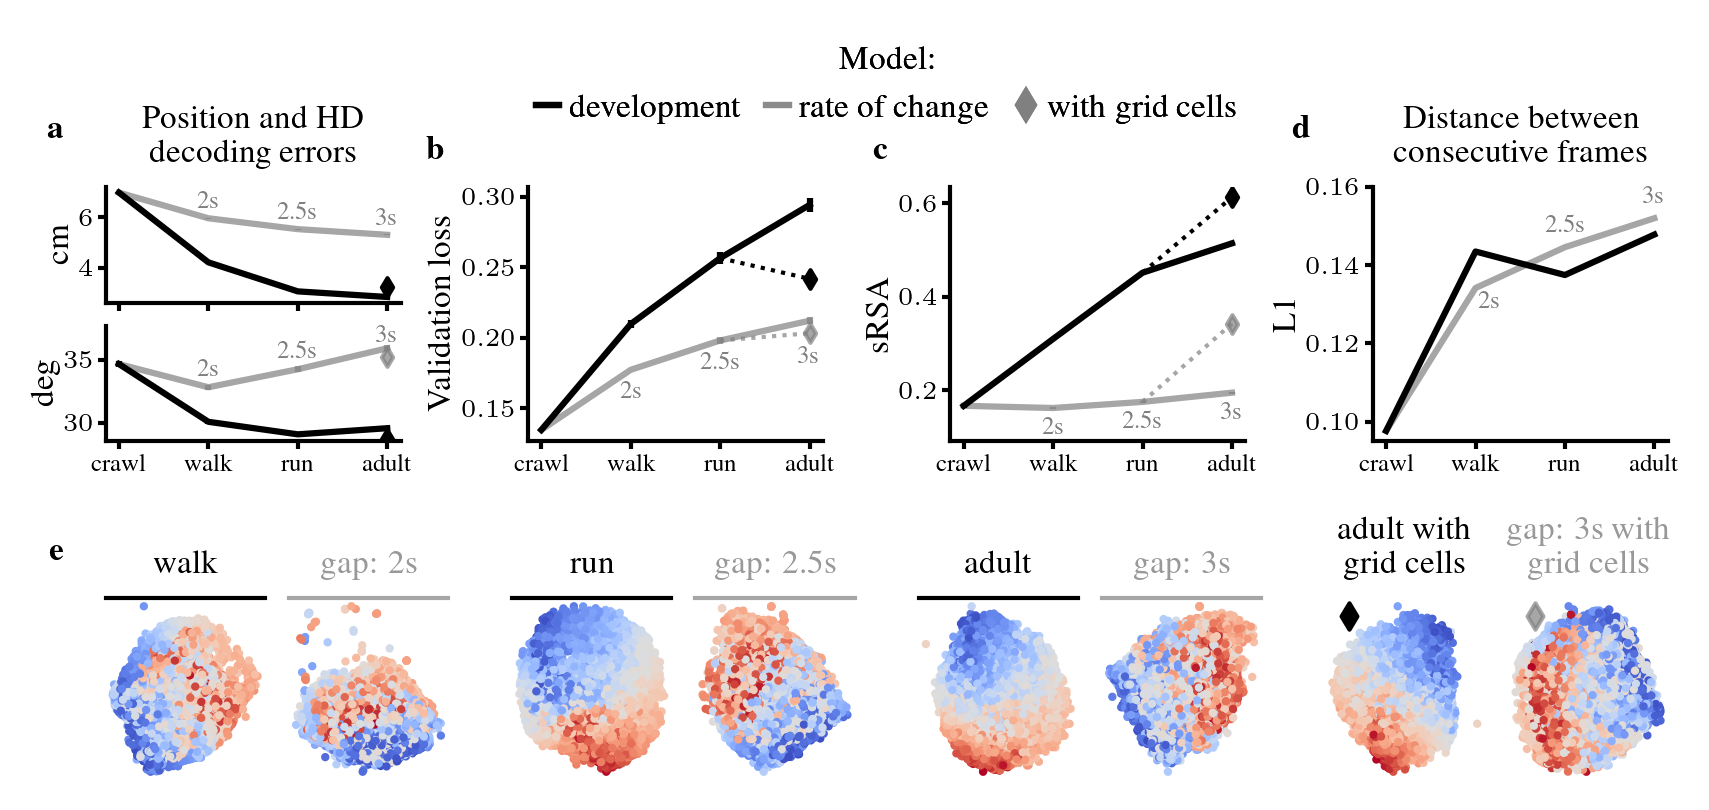

In [54]:
plt.style.use(os.path.join(BASE_DIR, 'matplotlib_style.mplstyle'))
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{times}'
plt.rcParams['font.family'] = 'serif'

fig, axs = plt.subplots(
    3, 4, figsize=(5.5, 2.5),
    height_ratios=(0.001,1.4,1), width_ratios=(1,1,1,1),
    dpi=300,
    # layout="constrained"
)

gs = axs.flat[0].get_gridspec()
for i in range(4):
    axs.flat[i].remove()
ax_g = fig.add_subplot(gs[0, :])
gs_c = ax_g.get_subplotspec()
fig.delaxes(ax_g)

nested_gs = gs_c.subgridspec(1,1, wspace=0, hspace=0)
ax = fig.add_subplot(nested_gs[0])
ax.set_axis_off()

import matplotlib.lines as mlines
d_line = mlines.Line2D([], [], color='black', label='development')
roc_line = mlines.Line2D([], [], color='gray', alpha=0.7, label='rate of change')
gc_m = mlines.Line2D(
    [], [], linestyle='none',
    marker='d', color='gray', label='with grid cells', markersize=5
)
l = ax.legend(
    handles=[d_line, roc_line, gc_m],
    title='Model:', title_fontsize=8,
    loc='upper center', ncol=3, frameon=False, handlelength=0.7,
    fontsize=8, borderpad=0, labelspacing=0.5, handletextpad=0.3,
    columnspacing=0.8
)
l.get_title().set_ha("left")
plt.setp(l.get_title(), horizontalalignment='left')
ax.add_artist(l)

###############################################################
### PLOT 1 ##################################################
ax = axs.flat[0+4]
gs_c = ax.get_subplotspec()
fig.delaxes(ax)

nested_gs = gs_c.subgridspec(2, 1, height_ratios=(1,1), hspace=0.2, wspace=0)

axtop = fig.add_subplot(nested_gs[0, 0])
axtop.annotate(
    r'\textbf{a}', xy=(0, 1), xycoords='axes fraction',
    xytext=(-10, 10), textcoords='offset points',
    ha='right', va='bottom'
)

m = [np.mean(p)*100 for p in poserr_all_dev]
sem = [np.std(p)*100 / np.sqrt(len(p)) for p in poserr_all_dev]
axtop.plot(range(len(m)), m, c='black')
for i in range(len(m)):
    axtop.errorbar(i, m[i], yerr=sem[i], fmt='none', c='black', capsize=0, zorder=5)
axtop.scatter(3, np.mean(poserr_all_dev_gc)*100, c='black', marker='d', s=10)

m = [np.mean(p)*100 for p in poserr_all_roc]
sem = [np.std(p)*100 / np.sqrt(len(p)) for p in poserr_all_roc]
axtop.plot(ticks_roc, m, c='gray', alpha=0.7, zorder=-10)
for i, x in enumerate(ticks_roc):
    if i == 0 : continue
    axtop.errorbar(x, m[i], yerr=sem[i], fmt='none', c='gray', alpha=0.7, capsize=0, zorder=5)
    axtop.text(x, m[i]+0.4, LABELS_ROC[i], ha='center', c='gray', zorder=10, fontsize=6)

axtop.set_xticks(range(len(poserr_all_dev)), [])
axtop.set_ylabel('cm')
# axtop.set_yticks([3, 4, 5, 6, 7])
axtop.spines[['right', 'top']].set_visible(False)
axtop.set_title('Position and HD\ndecoding errors')

axbottom = fig.add_subplot(nested_gs[1, 0])

m = [np.mean(y)*180/np.pi for y in hderr_all_dev]
sem = [np.std(y)*180/np.pi / np.sqrt(len(y)) for y in hderr_all_dev]
axbottom.plot(range(len(m)), m, c='black')
for i in range(len(m)):
    axbottom.errorbar(i, m[i], yerr=sem[i], fmt='none', c='black', capsize=0, zorder=5)
axbottom.scatter(3, np.mean(hderr_all_dev_gc)*180/np.pi, c='black', marker='d', s=10)

m = [np.mean(y)*180/np.pi for y in hderr_all_roc]
sem = [np.std(y)*180/np.pi / np.sqrt(len(y)) for y in hderr_all_roc]
axbottom.plot(ticks_roc, m, c='gray', alpha=0.7, zorder=-10)
for i, x in enumerate(ticks_roc):
    if i == 0 : continue
    axbottom.errorbar(x, m[i], yerr=sem[i], fmt='none', c='gray', alpha=0.7, capsize=0, zorder=5)
    if i < 3: axbottom.text(x, m[i]+0.9, LABELS_ROC[i], ha='center', c='gray', zorder=10, fontsize=6)
    else: axbottom.text(x, m[i]+0.5, LABELS_ROC[i], ha='center', c='gray', zorder=10, fontsize=6)
axbottom.scatter(3, np.mean(hderr_all_roc_gc)*180/np.pi, c='gray', alpha=0.7, marker='d', s=10)

axbottom.set_ylabel('deg')
axbottom.set_xticks(range(len(poserr_all_dev)), LABELS_DEV)
axbottom.set_ylim([28.5, 37.7])
axbottom.spines[['right', 'top']].set_visible(False)


###############################################################
### PLOT 2 ####################################################
ax = axs.flat[1+4]
ax.annotate(
    r'\textbf{b}', xy=(0, 1), xycoords='axes fraction',
    xytext=(-20, 5), textcoords='offset points',
    ha='right', va='bottom'
)

m = [np.mean(y) for y in loss_wo_selected_dev]
sem = [np.std(y) / np.sqrt(len(y)) for y in loss_wo_selected_dev]
ax.plot(range(len(m)), m, c='black')
for i in range(len(m)):
    ax.errorbar(i, m[i], yerr=sem[i], fmt='none', c='black', capsize=0, zorder=5)
ax.scatter(3, np.mean(loss_wo_selected_dev_gc), c='black', marker='d', s=10)
ax.plot([2,3], [m[-2], np.mean(loss_wo_selected_dev_gc)], c='black', linestyle=ls_gc, lw=1)
    
m = [np.mean(y) for y in loss_wo_selected_roc]
sem = [np.std(y) / np.sqrt(len(y)) for y in loss_wo_selected_roc]
ax.plot(ticks_roc, m, c='gray', alpha=0.7, zorder=-10)
for i, x in enumerate(ticks_roc):
    if i == 0 : continue
    ax.errorbar(x, m[i], yerr=sem[i], fmt='none', c='gray', alpha=0.7, capsize=0, zorder=5)
    if i < 3: ax.text(x, m[i]-0.02, LABELS_ROC[i], ha='center', c='gray', zorder=10, fontsize=6)
    else: ax.text(x, m[i]-0.03, LABELS_ROC[i], ha='center', c='gray', zorder=10, fontsize=6)
ax.scatter(3, np.mean(loss_wo_selected_roc_gc), c='gray', alpha=0.7, marker='d', s=10)
ax.plot([2,3], [m[-2], np.mean(loss_wo_selected_roc_gc)], c='gray', alpha=0.7, linestyle=ls_gc, lw=1)

ax.set_xticks(range(len(loss_wo_selected_dev)), LABELS_DEV)
ax.set_ylabel('Validation loss')
# ax.set_yticks([0.15, 0.2, 0.25])
ax.spines[['right', 'top']].set_visible(False)



###############################################################
### PLOT 3 ####################################################
ax = axs.flat[2+4]
ax.annotate(
    r'\textbf{c}', xy=(0, 1), xycoords='axes fraction',
    xytext=(-15, 5), textcoords='offset points',
    ha='right', va='bottom'
)
ax.set_ylabel('sRSA')

m = [np.mean(y) for y in sRSA_dev]
sem = [np.std(y) / np.sqrt(len(y)) for y in sRSA_dev]
ax.plot(m, c='black', label='Modeled')
for i in range(len(m)):
    ax.errorbar(i, m[i], yerr=sem[i], fmt='none', c='black', capsize=0, zorder=5)
ax.scatter(3, np.mean(sRSA_dev_gc), c='black', marker='d', s=10)
ax.plot([2,3], [m[-2], np.mean(sRSA_dev_gc)], c='black', linestyle=ls_gc, lw=1)

m = [np.mean(d) for d in sRSA_roc]
sem = [np.std(d) / np.sqrt(len(d)) for d in sRSA_roc]
ax.plot(ticks_roc, m, c='gray', alpha=0.7, zorder=-10)
for i, x in enumerate(ticks_roc):
    if i == 0 : continue
    ax.errorbar(x, m[i], yerr=sem[i], fmt='none', c='gray', alpha=0.7, capsize=0, zorder=5)
    ax.text(x, m[i]-0.055, LABELS_ROC[i], ha='center', c='gray', zorder=10, fontsize=6)
    # else: ax.text(x, m[i]-0.055, LABELS_ROC[i], ha='center', c='gray', zorder=10, fontsize=6)
ax.scatter(3, np.mean(sRSA_roc_gc), c='gray', alpha=0.7, marker='d', s=10)
ax.plot([2,3], [m[-2], np.mean(sRSA_roc_gc)], c='gray', alpha=0.7, linestyle=ls_gc, lw=1)

ax.set_xticks(range(len(sRSA_dev)), LABELS_DEV)
ax.set_yticks([0.2,0.4,0.6])
ax.set_ylim(bottom=0.09)
ax.spines[['right', 'top']].set_visible(False)


###############################################################
### PLOT 4 ####################################################
ax = axs.flat[3+4]
ax.annotate(
    r'\textbf{d}', xy=(0, 1), xycoords='axes fraction',
    xytext=(-15, 10), textcoords='offset points',
    ha='right', va='bottom'
)

y_mean = distance_inputs_dev
ax.plot(y_mean, c='black')
# for i in range(len(y_sem)):
#     ax.errorbar(i, y_mean[i], yerr=y_sem[i], fmt='none', c='black', capsize=1, zorder=4)

m = distance_inputs_roc
ax.plot(ticks_roc, m, c='gray', alpha=0.7, zorder=-10)
for i, x in enumerate(ticks_roc):
    if i == 0 : continue
    # ax.errorbar(x, m[i], yerr=sem[i], fmt='none', c='gray', alpha=0.7, capsize=0, zorder=5)
    if i < 2: ax.text(x+0.15, m[i]-0.005, LABELS_ROC[i], ha='center', c='gray', zorder=10, fontsize=6)
    else: ax.text(x, m[i]+0.004, LABELS_ROC[i], ha='center', c='gray', zorder=10, fontsize=6)

ax.set_ylabel('L1')
# ax.set_ylabel('L1 distance between\nconsecutive frames')
ax.set_title('Distance between\nconsecutive frames')
ax.set_yticks([0.10, 0.12, 0.14, 0.16])
ax.set_xticks(range(len(distance_inputs_dev)), LABELS_DEV)
ax.spines[['right', 'top']].set_visible(False)


###############################################################
### PLOT 6-8 ##################################################
labels_isomap_dev = ['crawl', 'walk', 'run', 'adult', 'adult with\ngrid cells']
labels_isomap_roc = ['', '2s', '2.5s', '3s', '3s with\ngrid cells']

gs = axs.flat[4+4].get_gridspec()
for i in range(4):
    axs.flat[i+4+4].remove()

ax_g = fig.add_subplot(gs[2, :])
gs_c = ax_g.get_subplotspec()
fig.delaxes(ax_g)

nested_gs = gs_c.subgridspec(1, 11, width_ratios=(1,1, 0.1, 1,1, 0.1, 1,1, 0.1, 1,1), wspace=0.2)

for c, idx in enumerate(range(0, 10, 3)):
    ax = fig.add_subplot(nested_gs[idx])
    if idx == 0:
        ax.annotate(
            r'\textbf{e}', xy=(0, 1), xycoords='axes fraction',
            xytext=(-10, 7.5), textcoords='offset points',
            ha='right', va='bottom'
        )

    ax.scatter(
        emb_dev[c+1][:, 0], emb_dev[c+1][:, 1],
        c=pos_dev[c+1].sum(axis=-1), cmap='coolwarm', s=1
    )
    # if c+1 == 3: ax.set_xlim(ax.get_xlim()[0], ax.get_xlim()[1]-0.07)
    ax.set_title(labels_isomap_dev[c+1])
    # ax.set_axis_off()
    ax.set_xticks([])
    ax.set_yticks([])
    if c!=3:
        ax.spines[['left', 'right', 'bottom']].set_visible(False)
    else:
        ax.scatter(min(emb_dev[c+1][:, 0])+0.05, max(emb_dev[c+1][:, 1])-0.02, c='black', marker='d', s=20)
        ax.set_axis_off()

    ax = fig.add_subplot(nested_gs[idx+1])

    ax.scatter(
        emb_roc[c+1][:, 0], emb_roc[c+1][:, 1],
        c=pos_roc[c+1].sum(axis=-1), cmap='coolwarm', s=1
    )
    ax.set_title(f'gap: {labels_isomap_roc[c+1]}', color=('gray', 0.8))
    # ax.set_axis_off()
    ax.set_xticks([])
    ax.set_yticks([])
    if c!=3:
        ax.spines[['left', 'right', 'bottom']].set_visible(False)
        ax.spines['top'].set_color(('gray', 0.7))
    else:
        ax.scatter(
            min(emb_roc[c+1][:, 0])+0.03, max(emb_roc[c+1][:, 1])-0.012,
            c='gray', alpha=0.7, marker='d', s=20
        )
        ax.set_axis_off()
    

# fig.get_layout_engine().set(h_pad=0.05, w_pad=0.05) #, hspace=0, wspace=0)

plt.tight_layout(w_pad=0.4, pad=0, h_pad=1.2)
# from matplotlib._layoutgrid import plot_children
# plot_children(fig)
plt.savefig(
    os.path.join(BASE_DIR, 'paper_figures', 'figure_roc_comparison.pdf'),
    dpi=300, bbox_inches='tight', pad_inches=0.02
)
plt.show()

# End